
# Comparación estructural entre objetos sc/snRNA-seq

## Objetivos

1. Comparar la calidad de integración (scIB metrics).
2. Comparar embeddings UMAP.
3. Comparar clustering.
4. Evaluar conservación de vecindarios celulares.
5. Analizar cambios topológicos inducidos por ncRNAs.
6. Generar un resumen ejecutivo reproducible.


In [14]:
import importlib.util

packages = {
    "scib_metrics": "scib-metrics",
    "scanpy": "scanpy",
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "scipy": "scipy"
}

for import_name, pip_name in packages.items():
    if importlib.util.find_spec(import_name) is not None:
        print(f"{import_name}: instalado")
    else:
        print(f"{import_name}: NO instalado → instalar con pip install {pip_name}")

scib_metrics: NO instalado → instalar con pip install scib-metrics
scanpy: instalado
pandas: instalado
numpy: instalado
matplotlib: instalado
seaborn: instalado
sklearn: instalado
scipy: instalado


In [15]:
%pip install scib-metrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 90.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 MB 120.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 190.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [scib-metrics] [chex]b]n-it-py]
Note: you may need to restart the kernel to use updated packages.


In [16]:

import scanpy as sc
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score
)

from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import cdist


In [17]:
from scib_metrics.benchmark import Benchmarker
from scib_metrics.benchmark import BioConservation, BatchCorrection

## Carga de datos

In [19]:

adata_coding = sc.read_h5ad("adata_coding_integrated.h5ad")
adata_ncrna = sc.read_h5ad("adata_ncrna_integrated.h5ad")


In [20]:
bm_coding = Benchmarker(
    adata_coding,
    batch_key="Sample",
    label_key="annotation",
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    embedding_obsm_keys=["X_pca_combat"],
    n_jobs=5,
)
bm_coding.benchmark()

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/scib_metrics/benchmark/_core.py:193: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(self._adata, svd_solver=self._solver, use_highly_variable=False)
Metrics:  60%|██████    | 6/10 [03:03<01:16, 19.24s/it, Batch correction: kbet_per_label]

INFO     Myofibroblasts consists of a single batch or is too small. Skip.                                          



Metrics:  70%|███████   | 7/10 [04:29<02:02, 40.92s/it, Batch correction: graph_connectivity]/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)

Embeddings: 100%|██████████| 1/1 [04:30<00:00, 270.42s/it]tch correction: pcr_comparison]

                                                                                         

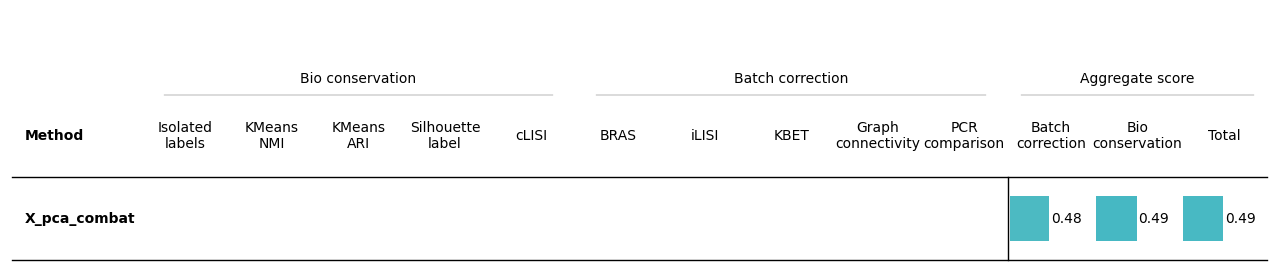

In [21]:
bm_coding.plot_results_table()

In [22]:
from rich import print

df_coding = bm_coding.get_results(min_max_scale=False)
print(df_coding)

Isolated labels        KMeans NMI        KMeans ARI  \
Embedding                                                            
X_pca_combat          0.348892          0.368618          0.246901   
Metric Type   Bio conservation  Bio conservation  Bio conservation   

              Silhouette label             cLISI              BRAS  \
Embedding                                                            
X_pca_combat          0.515059          0.970536          0.706483   
Metric Type   Bio conservation  Bio conservation  Batch correction   

                         iLISI              KBET Graph connectivity  \
Embedding                                                             
X_pca_combat           0.00321          0.112544           0.567583   
Metric Type   Batch correction  Batch correction   Batch correction   

                PCR comparison Batch correction Bio conservation  \
Embedding                                                          
X_pca_combat          0.999944         0.477953         0.490001   
Metric Type   Batch correction  Aggregate score  Aggregate score   

                        Total  
Embedding                      
X_pca_combat         0.485182  
Metric Type   Aggregate score

In [23]:
df_coding.to_csv("metrics_coding.csv")

In [24]:
bm_ncrna = Benchmarker(
    adata_ncrna,
    batch_key="Sample",
    label_key="annotation",
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    embedding_obsm_keys=["X_pca_combat"],
    n_jobs=5,
)
bm_ncrna.benchmark()

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/scib_metrics/benchmark/_core.py:193: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(self._adata, svd_solver=self._solver, use_highly_variable=False)
Metrics:  60%|██████    | 6/10 [02:11<00:52, 13.10s/it, Batch correction: kbet_per_label]

INFO     Myofibroblasts consists of a single batch or is too small. Skip.                                          



Metrics:  70%|███████   | 7/10 [02:40<00:54, 18.15s/it, Batch correction: graph_connectivity]/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)

Embeddings: 100%|██████████| 1/1 [02:41<00:00, 161.49s/it]tch correction: pcr_comparison]

                                                                                         

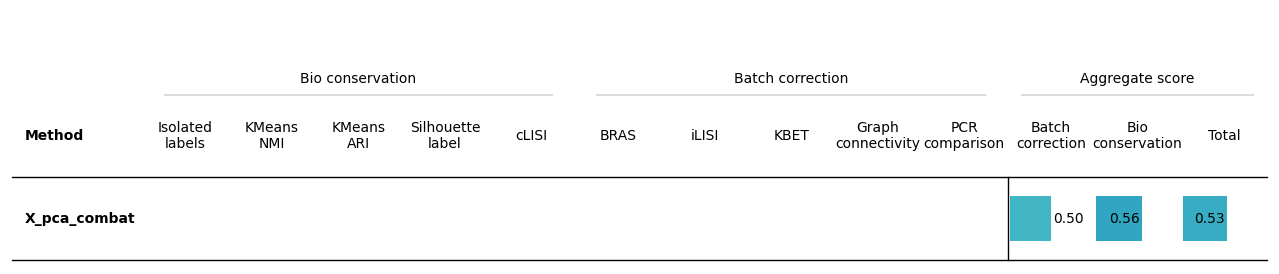

In [25]:
bm_ncrna.plot_results_table()

In [26]:
from rich import print

df_ncrna = bm_ncrna.get_results(min_max_scale=False)
print(df_ncrna)

Isolated labels        KMeans NMI        KMeans ARI  \
Embedding                                                            
X_pca_combat          0.433377          0.473051          0.352337   
Metric Type   Bio conservation  Bio conservation  Bio conservation   

              Silhouette label             cLISI              BRAS  \
Embedding                                                            
X_pca_combat          0.525361          0.995394          0.720089   
Metric Type   Bio conservation  Bio conservation  Batch correction   

                         iLISI              KBET Graph connectivity  \
Embedding                                                             
X_pca_combat          0.003402          0.125113           0.641513   
Metric Type   Batch correction  Batch correction   Batch correction   

                PCR comparison Batch correction Bio conservation  \
Embedding                                                          
X_pca_combat          0.999871         0.497998         0.555904   
Metric Type   Batch correction  Aggregate score  Aggregate score   

                        Total  
Embedding                      
X_pca_combat         0.532741  
Metric Type   Aggregate score

In [27]:
df_ncrna.to_csv("metrics_ncrna.csv")

## Comparación de métricas scIB

In [28]:

metrics_coding = pd.read_csv("metrics_coding.csv", index_col=0)
metrics_ncrna = pd.read_csv("metrics_ncrna.csv", index_col=0)

coding_scores = metrics_coding.loc["X_pca_combat"].astype(float)
ncrna_scores = metrics_ncrna.loc["X_pca_combat"].astype(float)

comparison = pd.concat(
    [coding_scores, ncrna_scores],
    axis=1
)

comparison.columns = ["Coding", "Coding_ncRNA"]
comparison


,Coding,Coding_ncRNA
Isolated labels,0.348892,0.433377
KMeans NMI,0.368618,0.473051
KMeans ARI,0.246901,0.352337
Silhouette label,0.515059,0.525361
cLISI,0.970536,0.995394
BRAS,0.706484,0.720089
iLISI,0.003210,0.003402
KBET,0.112544,0.125113
Graph connectivity,0.567583,0.641513
PCR comparison,0.999944,0.999871


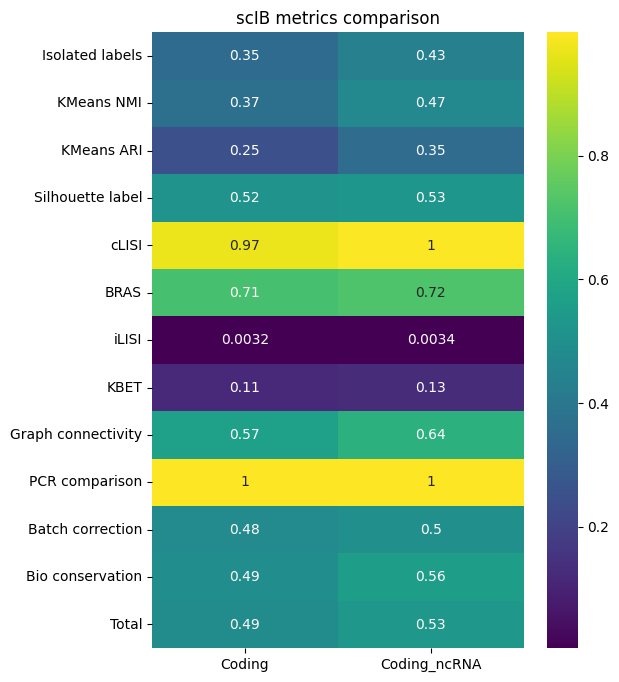

In [30]:

plt.figure(figsize=(6,8))
sns.heatmap(comparison, cmap="viridis", annot=True)
plt.title("scIB metrics comparison")
plt.show()


## Comparación visual de embeddings

In [31]:
adata_coding

AnnData object with n_obs × n_vars = 43570 × 30795
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score', 'leiden_combat_0_5', 'leiden_final', 'annotation', 'annotation_score'
    var: 'n_cells', 'highly_variable'
    uns: 'Condition_colors', 'Sample_colors', 'annotation_colors', 'leiden_combat_0_5', 'leiden_final_colors', 'log1p', 'neighbors', 'pca', 'preannotation_colors', 'umap'
    obsm: 'X_pca', 'X_pca_combat', 'X_umap'
    varm: 'PCs'
    layers: 'combat', 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

In [32]:
adata_ncrna

AnnData object with n_obs × n_vars = 39966 × 47611
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score', 'leiden_combat_0_5', 'leiden_final', 'annotation', 'annotation_score'
    var: 'n_cells', 'highly_variable'
    uns: 'Condition_colors', 'Sample_colors', 'annotation_colors', 'leiden_combat_0_5', 'leiden_final_colors', 'log1p', 'neighbors', 'pca', 'preannotation_colors', 'umap'
    obsm: 'X_pca', 'X_pca_combat', 'X_umap'
    varm: 'PCs'
    layers: 'combat', 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

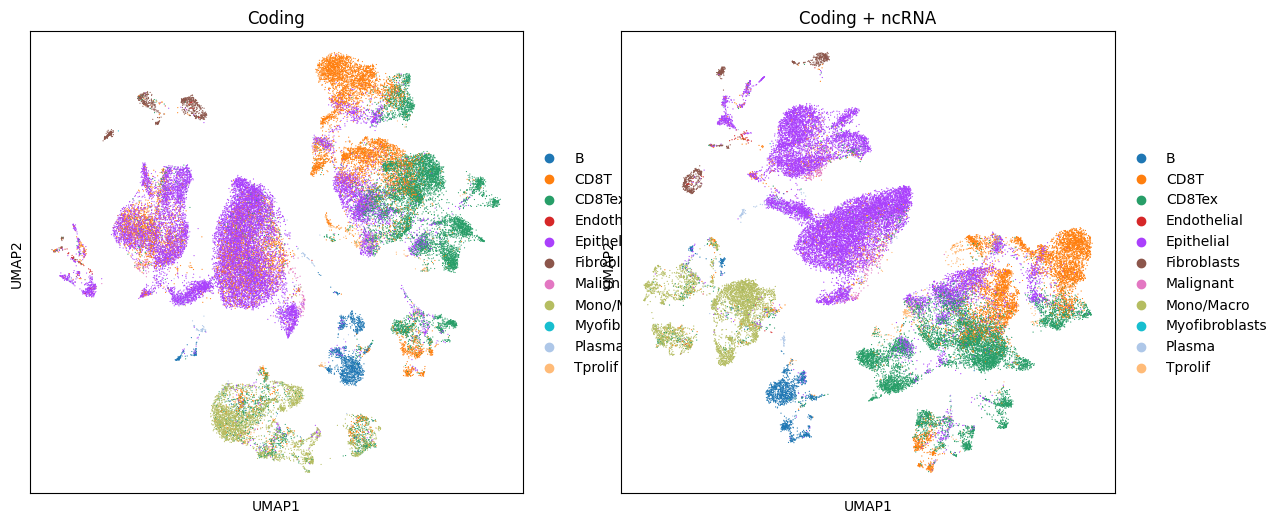

In [33]:

fig, ax = plt.subplots(1,2,figsize=(14,6))

# sc.pl.umap(
#     adata_coding,
#     color="cell_type",
#     ax=ax[0],
#     show=False
# )
sc.pl.umap(
    adata_coding,
    color="annotation",
    ax=ax[0],
    show=False
)

# sc.pl.umap(
#     adata_ncrna,
#     color="cell_type",
#     ax=ax[1],
#     show=False
# )
sc.pl.umap(
    adata_ncrna,
    color="annotation",
    ax=ax[1],
    show=False
)

ax[0].set_title("Coding")
ax[1].set_title("Coding + ncRNA")

plt.show()


## Comparación de clustering

In [34]:
# Ya que las dimensiones son distintas, no se puede ejecutar el código sin antes adaptarlo

# Find shared cells between both AnnData objects
common_cells = adata_coding.obs_names.intersection(adata_ncrna.obs_names)

print("Cells in adata_coding:", adata_coding.n_obs)
print("Cells in adata_ncrna:", adata_ncrna.n_obs)
print("Common cells:", len(common_cells))

# Extract Leiden labels for the same cells in the same order
coding_labels = adata_coding.obs.loc[common_cells, "leiden_final"].astype(str)
ncrna_labels = adata_ncrna.obs.loc[common_cells, "leiden_final"].astype(str)

# Safety check
assert coding_labels.index.equals(ncrna_labels.index)

# Compute clustering similarity metrics
ari = adjusted_rand_score(coding_labels, ncrna_labels)
nmi = normalized_mutual_info_score(coding_labels, ncrna_labels)

print("ARI:", ari)
print("NMI:", nmi)

Cells in adata_coding: 43570

Cells in adata_ncrna: 39966

Common cells: 39823

ARI: 0.9104905626657812

NMI: 0.9386173391839989

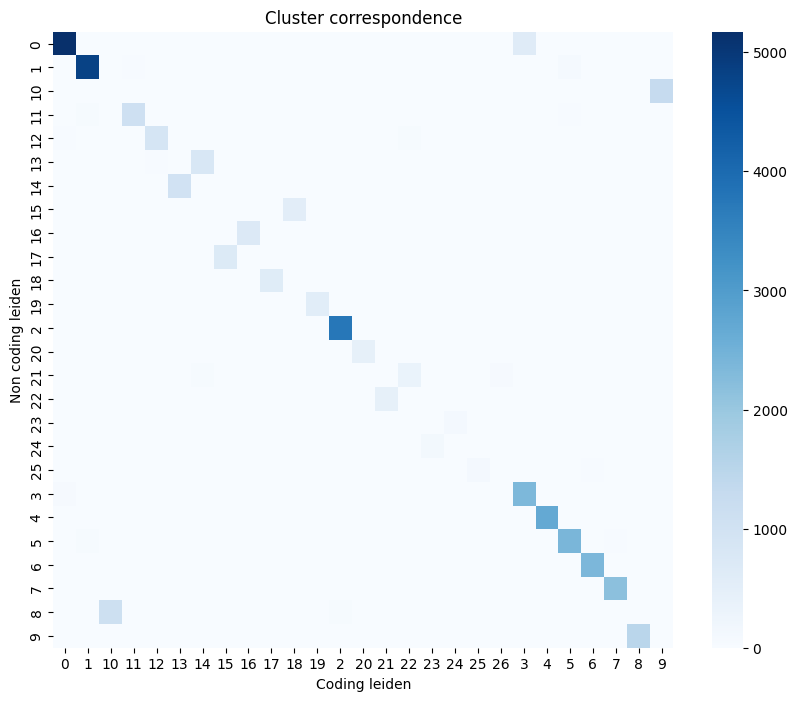

In [36]:
contingency = pd.crosstab(
    coding_labels,
    ncrna_labels
)

plt.figure(figsize=(10,8))
sns.heatmap(contingency, cmap="Blues")
plt.title("Cluster correspondence")
plt.xlabel("Coding leiden")
plt.ylabel("Non coding leiden")
plt.show()

## Conservación de vecindarios

In [38]:

def neighborhood_overlap(X1, X2, k=30):

    nn1 = NearestNeighbors(n_neighbors=k).fit(X1)
    nn2 = NearestNeighbors(n_neighbors=k).fit(X2)

    idx1 = nn1.kneighbors(return_distance=False)
    idx2 = nn2.kneighbors(return_distance=False)

    overlaps = []

    for a,b in zip(idx1, idx2):
        overlaps.append(
            len(set(a).intersection(set(b))) / k
        )

    return np.array(overlaps)


In [39]:
# Ya que no tienen las mismas dimensiones los objetos, alineo las células comunes.
common_cells = adata_coding.obs_names.intersection(adata_ncrna.obs_names)

print(len(common_cells))
# adata_coding_common = adata_coding[common_cells].copy()
# adata_ncrna_common = adata_ncrna[common_cells].copy()

X_coding = adata_coding[common_cells].obsm["X_pca_combat"]
X_ncrna = adata_ncrna[common_cells].obsm["X_pca_combat"]

print(X_coding.shape)
print(X_coding.shape)

39823

(39823, 50)

(39823, 50)

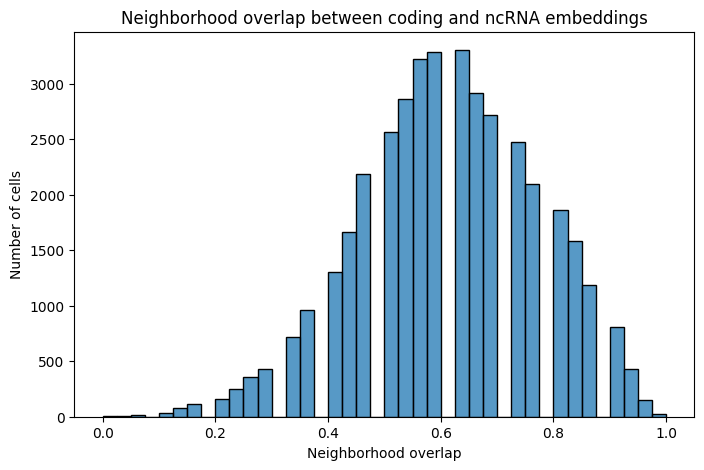

In [40]:

overlap = neighborhood_overlap(
    X_coding,
    X_ncrna
)

plt.figure(figsize=(8,5))
sns.histplot(overlap, bins=40)
plt.xlabel("Neighborhood overlap")
plt.ylabel("Number of cells")
plt.title("Neighborhood overlap between coding and ncRNA embeddings")
plt.show()


## Distancias entre tipos celulares

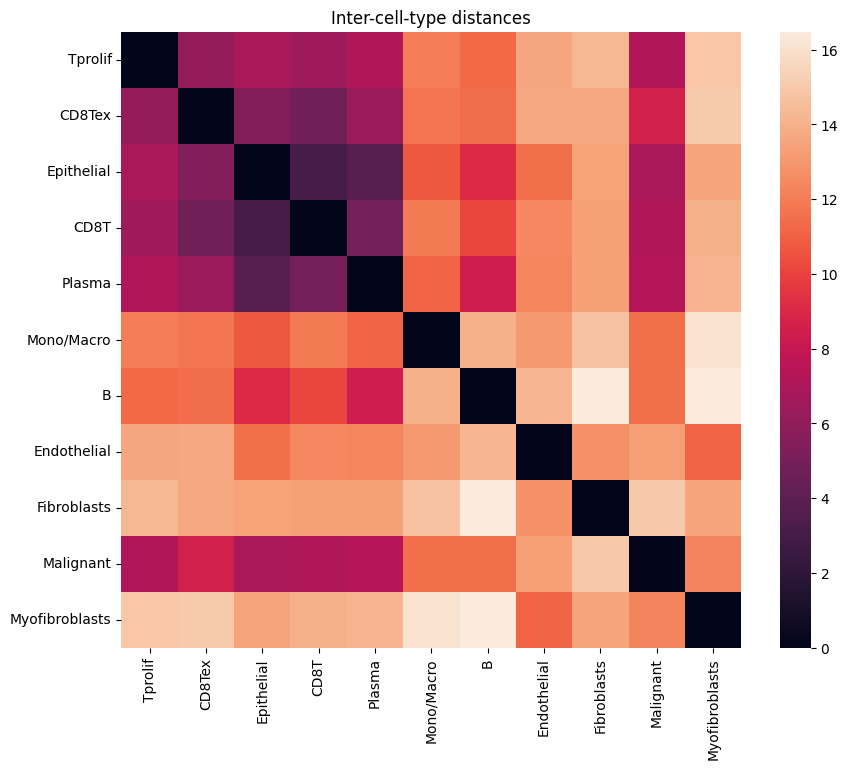

In [42]:

centroids = {}

for ct in adata_coding.obs["annotation"].unique():
    idx = adata_coding.obs["annotation"] == ct

    centroids[ct] = (
        adata_coding.obsm["X_pca_combat"][idx]
        .mean(axis=0)
    )

cts = list(centroids.keys())

M = np.vstack(
    [centroids[x] for x in cts]
)

D = cdist(M, M)

plt.figure(figsize=(10,8))
sns.heatmap(
    D,
    xticklabels=cts,
    yticklabels=cts
)
plt.title("Inter-cell-type distances")
plt.show()


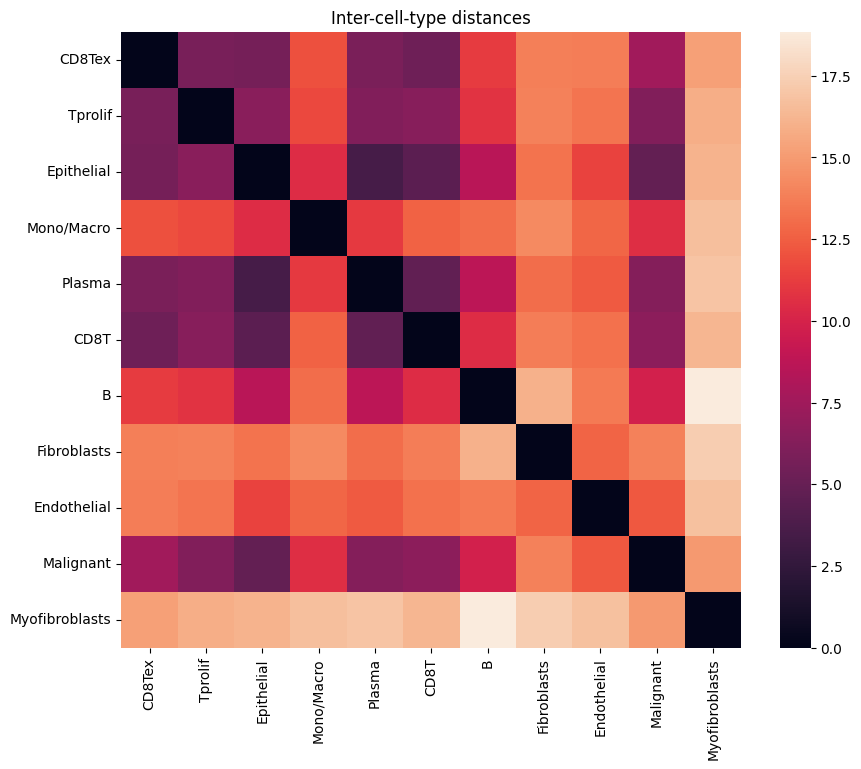

In [43]:

centroids = {}

for ct in adata_ncrna.obs["annotation"].unique():
    idx = adata_ncrna.obs["annotation"] == ct

    centroids[ct] = (
        adata_ncrna.obsm["X_pca_combat"][idx]
        .mean(axis=0)
    )

cts = list(centroids.keys())

M = np.vstack(
    [centroids[x] for x in cts]
)

D = cdist(M, M)

plt.figure(figsize=(10,8))
sns.heatmap(
    D,
    xticklabels=cts,
    yticklabels=cts
)
plt.title("Inter-cell-type distances")
plt.show()


## Resumen ejecutivo

In [45]:

summary = pd.DataFrame(
    {
        "Metric":[
            "ARI",
            "NMI",
            "Mean_neighbor_overlap"
        ],
        "Value":[
            ari,
            nmi,
            overlap.mean()
        ]
    }
)

summary


,Metric,Value
0,ARI,0.910491
1,NMI,0.938617
2,Mean_neighbor_overlap,0.611183
